<a href="https://colab.research.google.com/github/BorisLouis/ImageClassification_project2_OpenCV/blob/main/project2_competition_starter_notebook_r4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2: Kaggle Competition - Image Classification

#### Maximum Points: 100

<div align="center">
    <table>
        <tr><td><h3>Number</h3></td> <td><h3>Section</h3></td> <td><h3>Points</h3></td> </tr>
        <tr><td><h3>1</h3></td> <td><h3>Data Preparation</h3></td> <td><h3>20</h3></td> </tr>
        <tr><td><h3>2</h3></td> <td><h3>Share TensorBoard Logs</h3></td> <td><h3>10</h3></td></tr>
        <tr><td><h3>3</h3></td> <td><h3>Kaggle Submission Score</h3></td> <td><h3>70</h3></td></tr>
    </table>
</div>


**<font style="color:red">Please do not make your notebooks public or publish them on the competition page. You only need to submit your notebook to the lab. This is to make sure that students don't copy each other. You are free to take references from any online resource.</font>**

----------

**<font style="color:red">Points to Remember:</font>**

1. You need to achieve **at least `86%`** accuracy on the Public Test leaderboard for **minimum** marks to be awarded.
2. **Maximum** points will be awarded if your Public Test Leaderboard score is **`>=92%`**.
3. In this project for training, you can either use pre-trained models or the ones you create from scratch.

**Kaggle Submission Score Points Distribution**

<div align="center">
    <table>
        <tr><td><h3>Sr. no.</h3></td> <td><h3>Public Test Set Accuracy</h3></td> <td><h3>Points</h3></td></tr>
        <tr><td><h3>1</h3></td> <td><h3>>= 92%</h3></td> <td><h3>70</h3></td> </tr>
        <tr><td><h3>2</h3></td> <td><h3>91%</h3></td> <td><h3>60</h3></td> </tr>
        <tr><td><h3>3</h3></td> <td><h3>90%</h3></td> <td><h3>50</h3></td> </tr>
        <tr><td><h3>4</h3></td> <td><h3>89%</h3></td> <td><h3>40</h3></td> </tr>
        <tr><td><h3>5</h3></td> <td><h3>88%</h3></td> <td><h3>30</h3></td> </tr>
        <tr><td><h3>6</h3></td> <td><h3>87%</h3></td><td><h3>20</h3></td> </tr>
        <tr><td><h3>7</h3></td> <td><h3>86%</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>8</h3></td> <td><h3>< 86%</h3></td> <td><h3>0</h3></td> </tr>
    </table>
</div>

**Note: Percentages will be rounded off to the nearest integer.**

In [1]:
import os

#block to setup the path to the data to my google drive (Using Colab Pro, not Kaggle)
from google.colab import drive
drive.mount('/content/drive')

import sys, os

# Point to wherever you cloned the repo on Drive
REPO_DIR = '/content/drive/My Drive/GoogleColab/ImageClassification_project2_OpenCV'
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)  # also set working directory, fixes relative file paths inside notebooks


# get the data
!unzip -q "/content/opencv-tf-project-2-image-classification-round-4.zip" -d "/content"


# If required, update the ROOT_DIR path according to the dataset path.
ROOT_DIR = r"/content/"

IMG_DIR = os.path.join(ROOT_DIR, "sports_images", "all_images")

TRAIN_FILE = os.path.join(ROOT_DIR, "train.csv")

print("Contents:")
for i in os.listdir(ROOT_DIR):
    if os.path.isdir(os.path.join(ROOT_DIR, i)):
        print(f"\tDirectory: {i}")
    else:
        print(f"\tFile: {i}")

print(f"Total images: {len(os.listdir(IMG_DIR))}")

Mounted at /content/drive
Contents:
	Directory: .config
	File: opencv-tf-project-2-image-classification-round-4.zip
	File: train.csv
	File: test.csv
	Directory: sports_images
	File: sample_submission.csv
	Directory: drive
	Directory: sample_data
Total images: 11146


In [2]:
#import block
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from dataclasses import dataclass
import platform


In [3]:
# fix random seeds
SEED_VALUE = 42
def set_seeds():

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    tf.random.set_seed(SEED_VALUE)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"

    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            print(e)

#     physical_devices = tf.config.list_physical_devices("GPU")
#     try:
#         tf.config.experimental.set_memory_growth(physical_devices[0], True)
#     except:
#         # Invalid device or cannot modify virtual devices once initialized.
#         pass

    return

set_seeds()

## <font style="color:red">1 Data Preparation [20 Points]</font>



**There is no separate validation data. You will thus have to create your validation set by dividing the train data into train and validation data. Usually, we do an 80:20 ratio for train and validation, respectively.**

In this section, you can either the `Sequence` class or `tf.data` API or `image_dataset_from_directory` or any other method to create training and validation data generators.



For example:

```python
class SportsClassificationDataset(Sequence):

    def __init__(self, *args):
        ...
        ...

    def __getitem__(self, idx):
        ...
        ...
    def __len__(self):
        ...
        ...
    def on_epoch_end(self):
        ...
        ...
    
```

```python
def get_dataset(args1, *agrs):
    ...
    return train_dataset, test_dataset
```

#Splitting Data and training set

In [4]:
#split validation and train set
df = pd.read_csv(TRAIN_FILE)
train_df = df.sample(frac=0.8, random_state=42)
val_df = df.drop(train_df.index)

# Data Augmentation Pipeline


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential


def data_augmentation_preprocess():

  # Random rotation in either direction as a fraction of 2PI.
  rand_rotation = layers.RandomRotation(0.1,                 # = .1*2*PI = +/- 54 deg
                                        fill_mode='nearest',  # Fill points outside boundaries with nearest pixel.
                                        seed=SEED_VALUE)

  # Random horizontal flipping.
  rand_flip_hor = layers.RandomFlip("horizontal", seed=SEED_VALUE)


  # Random zooming.
  rand_zoom     = layers.RandomZoom(height_factor=(-.1, .1),  # Zooming IN/OUT, in height up to 50%
                                    width_factor=(-.1, .1),   # Zooming IN/OUT, in width up to 50%
                                    fill_mode='nearest',      # Fill points outside boundaries with nearest pixel.
                                    seed=SEED_VALUE)

  data_augmentation_pipeline = Sequential(
    [
        rand_rotation,
        rand_flip_hor,
        rand_zoom,
    ]

    )
  return data_augmentation_pipeline


# Dataloader

In [6]:
class SportsClassificationDataset(Sequence):

    def __init__(self, dataframe, image_paths, batch_size, image_size,augment):
      self.batch_size = batch_size
      self.image_size = image_size
      self.image_paths = image_paths
      self.augment = augment
      self.dataframe = dataframe
      self.num_classes = len(dataframe.CLASS.unique())
      self.class_names = sorted(dataframe.CLASS.unique())

      self.class_to_idx = {name: idx for idx, name in enumerate(self.class_names)}
      self.all_labels = dataframe.CLASS.map(self.class_to_idx).tolist()

      self.all_images = [os.path.join(self.image_paths, fname) for fname in self.dataframe.ID]

      joined_lists = list(zip(self.all_images, self.all_labels))
      #shuffle the joined list
      random.shuffle(joined_lists)
      #separate the lists again
      self.all_images, self.all_labels = zip(*joined_lists)

      self.all_labels = tf.keras.utils.to_categorical(self.all_labels,self.num_classes)

      self.image = np.empty((self.batch_size,) + self.image_size + (3,),dtype="float32")
      self.label = np.empty((self.batch_size, self.num_classes), dtype="float32")

      #build preprocessing pipeline:
      if self.augment:
        self.augmentor = data_augmentation_preprocess()

    def __len__(self):
      return len(self.dataframe) // self.batch_size

    def __getitem__(self, idx):

      batch_images = self.all_images[idx * self.batch_size : (idx + 1) * self.batch_size]
      batch_labels = self.all_labels[idx * self.batch_size : (idx + 1) * self.batch_size]

      for j, file_name in enumerate(batch_images):
        self.image[j] = cv2.resize(cv2.cvtColor(cv2.imread(file_name), cv2.COLOR_BGR2RGB), self.image_size)
        self.label[j] = batch_labels[j]

      if self.augment:
        self.image = self.augmentor(self.image, training=True).numpy()

      return self.image, self.label

    def on_epoch_end(self):
      joined_lists = list(zip(self.all_images, self.all_labels))
      random.shuffle(joined_lists)
      self.all_images, self.all_labels = zip(*joined_lists)
      self.all_images = list(self.all_images)
      self.all_labels = np.array(self.all_labels)


#Dataset exploration

(32, 300, 300, 3)
(32, 73)


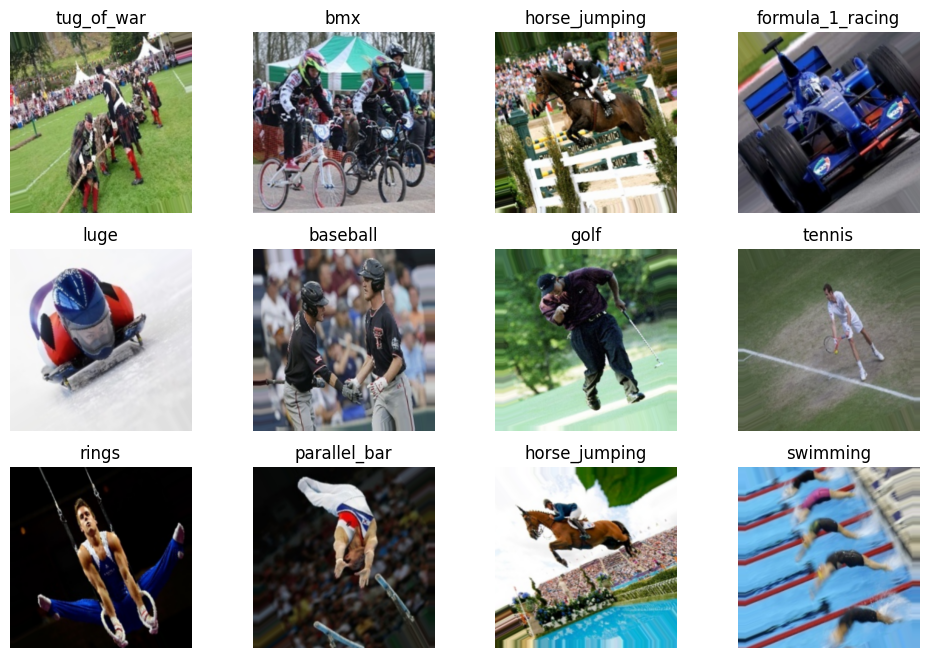

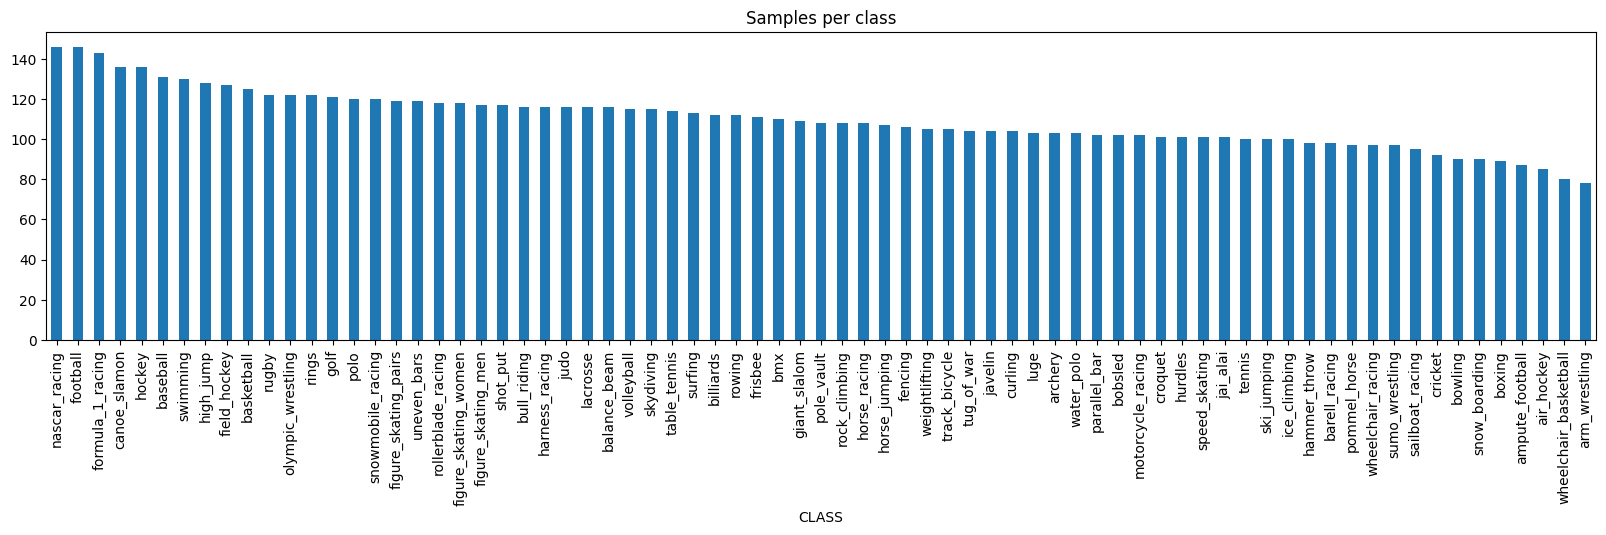

In [7]:
train_dataset = SportsClassificationDataset(
    dataframe=train_df,
    image_paths= IMG_DIR,
    batch_size=32,
    image_size=(300, 300),
    augment=True
)

# Get one batch
images, labels = train_dataset[0]
print(images.shape)
print(labels.shape)

# Visualize a few images
fig, axes = plt.subplots(3, 4, figsize=(12, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].astype('uint8'))
    class_idx = np.argmax(labels[i])
    ax.set_title(train_dataset.class_names[class_idx])
    ax.axis('off')
plt.show()


train_df['CLASS'].value_counts().plot(kind='bar', figsize=(20, 4))
plt.title('Samples per class')
plt.show()

## 2 Configuration

**Define your configuration here.**

For example:


```python
@dataclass
class TrainingConfig:
    BATCH_SIZE: int = 10
    EPOCHS: int = 10
    LEARNING_RATE: float = 0.1
    use_multiprocessing: bool = False
    num_workers: int = 4
    ...
    ...
```

```python
@dataclass
class DatasetConfig:
    DATA_ROOT: str = r"../input/opencv-TF-course-project-2-image-classification/sports_images/all_images"
    DATA_SHAPE: tuple = (224, 224, 3)
    NUM_CLASSES: int = 4
```

In [8]:
DISTRIBUTE_STRATEGY = tf.distribute.MirroredStrategy()
@dataclass
class TrainingConfig:
    # Defining the batch size for model training.
    # The batch size is set to be some integer times the  number of devices in synchronization as per the distributed strategy.
    # This means that the overall batch of data is divided equally across all the devices used in the distributed training.
    # By scaling the batch size with the number of replicas (devices), each device processes a batch of size, in this case, 4.

    # This approach helps in efficient utilization of the computational power of all the devices involved in training.
    BATCH_SIZE: int = 64 * DISTRIBUTE_STRATEGY.num_replicas_in_sync

    EPOCHS: int = 35
    LEARNING_RATE: float = 0.0002

    # For tensorboard logging and saving checkpoints
    root_log_dir = os.path.join("Logs_Checkpoints", "Model_logs")
    root_checkpoint_dir = os.path.join("Logs_Checkpoints", "Model_checkpoints")

    # Current log and checkpoint directory.
    log_dir = "version_0"
    checkpoint_initial = "version_0"

    # Use multiprocessing during training.
    use_multiprocessing: bool = True if platform.system() == "Linux" else False

    # Number of workers to use for training.
    num_workers: int = 4

In [9]:
@dataclass
class DatasetConfig:
    DATA_ROOT: str = IMG_DIR
    DATA_SHAPE: tuple = (300, 300, 3)
    NUM_CLASSES: int = 73

## 3 Model



**Define your models here.**


```python
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Rescaling
)


def create_model(num_classes=73, input_shape=(224, 224, 3), name="Dummy_Model"):
    ...
    ...
    ...
    
    # return your model
    return model
  
```

Given the relatively small amount of image and the number of classes and the complexity of the problem (sometimes have to distinguish between sport that are similar), the best strategy seems to use a pre-trained network and fine-tune it to the specific dataset.

First, let's train the just the classifying layer and see where we land, then we will unfreeze layer if needed.

In [10]:

from tensorflow.keras import Model, Input
from tensorflow.keras.layers import (
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Rescaling
)
# we start from Effnet
def create_model(num_classes=73, input_shape=(224, 224, 3), name="BoLo_Model"):
    EffNet_conv_base = tf.keras.applications.EfficientNetB3(
        input_shape = input_shape,
        include_top=False,
        weights='imagenet',)
    EffNet_conv_base.trainable = False
    inputs = Input(shape=input_shape)
    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = EffNet_conv_base(x)
    x = GlobalAveragePooling2D()(x)
    #x = Dense(512, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    # return your model
    return model



#CallBacks

In [11]:
def get_callbacks(
    training_config=TrainingConfig(),
    monitor="val_loss",
    mode="min",
    save_weights_only=False,
    save_best_only=True,
):

    # Initialize tensorboard callback for logging.
    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=training_config.log_dir,
        histogram_freq=3,
        write_graph=True,
        update_freq="epoch",
        write_images=True,
    )

    reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # halve the LR when plateauing
    patience=3,      # wait 3 epochs before reducing
    min_lr=1e-6,     # don't go below this
    verbose=1        # print when LR is reduced
)

    checkpoint_filepath = os.path.join(
    training_config.root_checkpoint_dir,
    training_config.checkpoint_initial
)

    # Update file path if saving best model weights.
    if save_weights_only:
        checkpoint_filepath = os.path.join(checkpoint_filepath, "model.ckpt")
    else:
        checkpoint_filepath = os.path.join(checkpoint_filepath, "model.keras")

    model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_filepath,
        save_weights_only=save_weights_only,
        monitor=monitor,
        mode=mode,
        save_best_only=save_best_only,
        verbose=0,
    )



    return [tensorboard_callback, model_checkpoint_callback]

# Log

In [12]:
def setup_log_directory(training_config=TrainingConfig()):
    '''Tensorboard Log, Model checkpoint directory Setup and Early stopping'''

    get_number = lambda path: path.replace(".keras", "").replace("version_", "")

    if os.path.isdir(training_config.root_log_dir):
        # Get all folders numbers in the root_log_dir
        folder_numbers = [int(get_number(folder)) for folder in os.listdir(training_config.root_log_dir)]

        # Find the latest version number present in the log_dir
        last_version_number = max(folder_numbers)

        # New version name
        version_name = f"version_{last_version_number + 1}"

    else:
        version_name = training_config.log_dir


    # Update the training config default directory
    training_config.log_dir        = os.path.join(training_config.root_log_dir,        version_name)
    training_config.checkpoint_path = os.path.join(training_config.root_checkpoint_dir, version_name)

    # Create new directory for saving new experiment version
    os.makedirs(training_config.log_dir, exist_ok=True)
    os.makedirs(training_config.root_checkpoint_dir, exist_ok=True)

    print(f"Logging at: {training_config.log_dir}")
    print(f"Model Checkpoint at: {training_config.checkpoint_path}")

    return training_config, version_name

#Plot

In [13]:
def plot_history(
    train_loss=None,
    val_loss=None,
    train_metric=None,
    val_metric=None,
    colors=["blue", "green"],
    loss_legend_loc="upper center",
    acc_legend_loc="upper left",
    fig_size=(15, 10),
):

    plt.rcParams["figure.figsize"] = fig_size
    fig = plt.figure()
    fig.set_facecolor("white")

    # Loss Plots
    plt.subplot(2, 1, 1)

    train_loss_range = range(len(train_loss))
    plt.plot(
        train_loss_range,
        train_loss,
        color=f"tab:{colors[0]}",
        label=f"Train Loss",
    )

    valid_loss_range = range(len(val_loss))
    plt.plot(
        valid_loss_range,
        val_loss,
        color=f"tab:{colors[1]}",
        label=f"Valid Loss",
    )

    plt.ylabel("Loss")
    plt.legend(loc=loss_legend_loc)
   # plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True)
    plt.title("Training and Validation Loss")

    # Accuracy Plots
    plt.subplot(2, 1, 2)

    train_metric_range = range(len(train_metric))
    plt.plot(
        train_metric_range,
        train_metric,
        color=f"tab:{colors[0]}",
        label=f"Train Accuracy",
    )

    val_metric_range = range(len(val_metric))
    plt.plot(
        val_metric_range,
        val_metric,
        color=f"tab:{colors[1]}",
        label=f"Valid Accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    #plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.legend(loc=acc_legend_loc)
    plt.grid(True)
    plt.title("Training and Validation Accuracy")

    plt.show()

    return

#Training function

In [14]:
def train_model(
    dataset_config=DatasetConfig(),
    training_config=TrainingConfig(),
    data_augmentation=True,
    print_summary=True,
    train_df = train_df,
    val_df = val_df
):
    train_dataset = SportsClassificationDataset(
    dataframe=train_df,
    image_paths= dataset_config.DATA_ROOT,
    batch_size=training_config.BATCH_SIZE,
    image_size=dataset_config.DATA_SHAPE[:2],
    augment=data_augmentation
)
    valid_dataset = SportsClassificationDataset(
    dataframe=val_df,
    image_paths= dataset_config.DATA_ROOT,
    batch_size=training_config.BATCH_SIZE,
    image_size=dataset_config.DATA_SHAPE[:2],
    augment=False
)
    for images, labels in valid_dataset:
        print("X Shape:", images.shape, "Y Shape:", labels.shape)
        break

    # Start a context manager using the distributed strategy previously defined.
    # This scope ensures that the operations defined within it are distributed across the available devices as per the strategy.
    with DISTRIBUTE_STRATEGY.scope():
        # Get the model by calling the 'get_model' function.
        model = create_model(num_classes=dataset_config.NUM_CLASSES, input_shape=dataset_config.DATA_SHAPE)

        # Compile the model. This step configures the model for training.
        # 'loss' is set to 'categorical_crossentropy', which is a common choice for classification tasks.
        # 'optimizer' is an Adam optimizer with a specific learning rate from the training configuration.
        # 'metrics' is a list of metrics to be evaluated by the model during training and testing, here it's set to track 'accuracy'.
        model.compile(
            loss="categorical_crossentropy",
            optimizer=tf.keras.optimizers.Adam(learning_rate=training_config.LEARNING_RATE),
            metrics=["accuracy"],
        )


    # Print model summary
    if print_summary:
        model.summary()

    # Get training callbacks
    callbacks = get_callbacks(training_config)

    # Train model
    training_results = model.fit(
        train_dataset,
        validation_data=valid_dataset,
        epochs=training_config.EPOCHS,
        callbacks=callbacks,
        #workers=training_config.num_workers,
        #use_multiprocessing=training_config.use_multiprocessing
    )

    print("training_results keys:", training_results.history.keys())

    return model, training_results

In [15]:
training_config = TrainingConfig()

# Tensorboard Log and model checkpoint Setup.
training_config, current_version_name = setup_log_directory(training_config)


# Start training
# Enable using cudNN.
os.environ['TF_USE_CUDNN'] = "true"


trained_model, training_results = train_model(
    dataset_config=DatasetConfig(),
    training_config=training_config,
    data_augmentation=True,
    train_df = train_df,
    val_df = val_df
)





Logging at: Logs_Checkpoints/Model_logs/version_12
Model Checkpoint at: Logs_Checkpoints/Model_checkpoints/version_12
X Shape: (64, 300, 300, 3) Y Shape: (64, 73)
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 73)             │       112,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,895,736 (41.56 MB)

 Trainable params: 112,201 (438.29 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 126s 922ms/step - accuracy: 0.1189 - loss: 3.9855 - val_accuracy: 0.6094 - val_loss: 2.8495
Epoch 2/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 127s 826ms/step - accuracy: 0.5785 - loss: 2.6359 - val_accuracy: 0.7631 - val_loss: 1.9096
Epoch 3/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 103s 826ms/step - accuracy: 0.7269 - loss: 1.8537 - val_accuracy: 0.8206 - val_loss: 1.3694
Epoch 4/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 113s 906ms/step - accuracy: 0.7827 - loss: 1.3971 - val_accuracy: 0.8548 - val_loss: 1.0512
Epoch 5/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 104s 829ms/step - accuracy: 0.8128 - loss: 1.1269 - val_accuracy: 0.8669 - val_loss: 0.8586
Epoch 6/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 142s 827ms/step - accuracy: 0.8359 - loss: 0.9589 - val_accuracy: 0.8805 - val_loss: 0.7245
Epoch 7/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 114s 910ms/step - accuracy: 0.8500 - loss: 0.8362 - val_accuracy: 0.8891 - val_loss: 0.6336
Epoch 8/35
125/125 ━━━━━━━━━━━━━━━━━━━━ 103s 826ms/step - accuracy: 0.8625 -

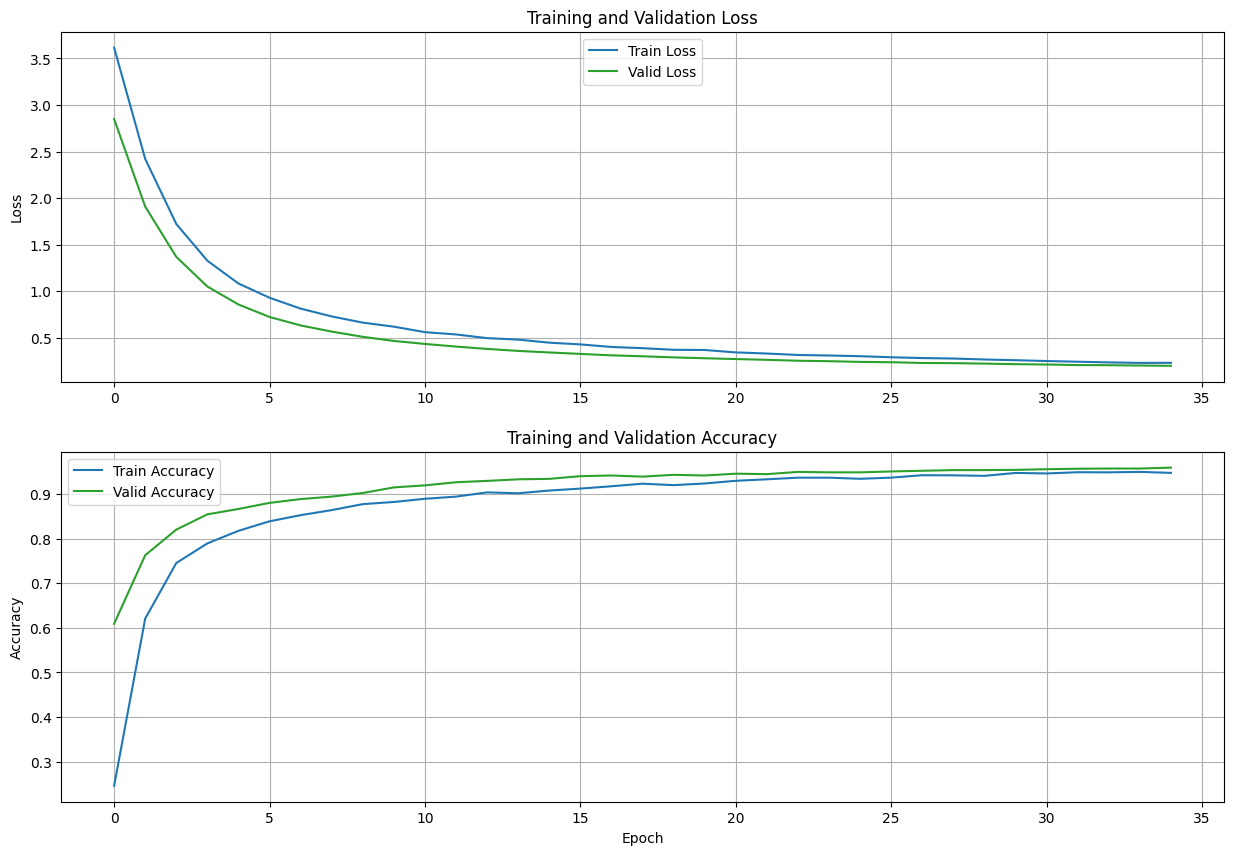

In [16]:
loss = training_results.history["loss"]
accuracy = training_results.history["accuracy"]

val_loss = training_results.history["val_loss"]
val_accuracy = training_results.history["val_accuracy"]

plot_history(
    train_loss=loss,
    train_metric=accuracy,
    val_loss=val_loss,
    val_metric=val_accuracy,
    loss_legend_loc="upper center",
    acc_legend_loc="upper left",
)

Generating Predictions...


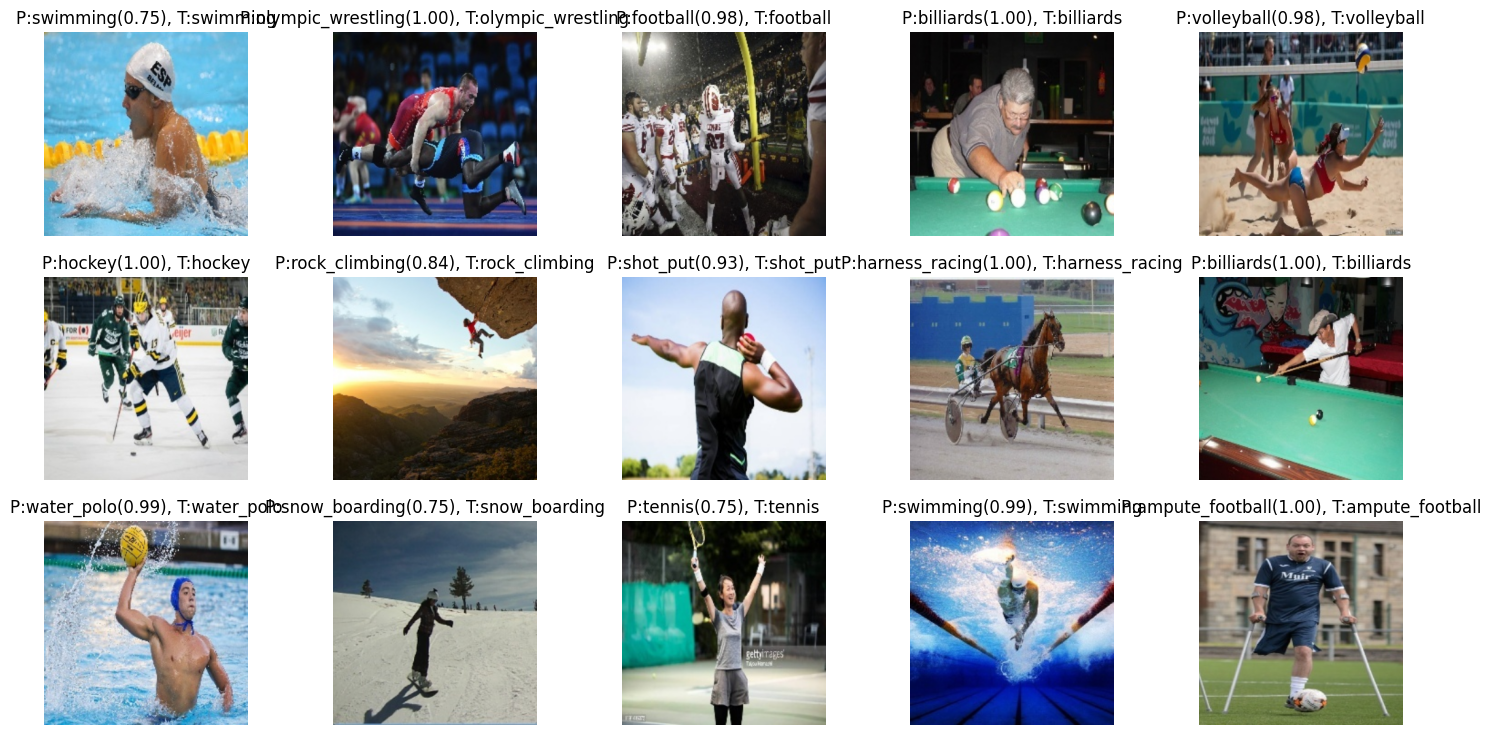

In [17]:
def get_sample_predictions(*, model, dataset, total=15):

    imgs = []
    ground_truths = []
    probs = []
    predictions = []

    idx_to_cls = {idx: name for name, idx in dataset.class_to_idx.items()}

    print("Generating Predictions...")
    for data, target in dataset:
        model_predictions = model.predict_on_batch(data)
        cls_predicted = np.argmax(model_predictions, axis=-1)
        cls_probs = np.max(model_predictions, axis=-1)

        imgs.extend(data)
        ground_truths.extend(target)
        predictions.extend(cls_predicted)
        probs.extend(cls_probs)

        # Displaying only 15 images
        if data.shape[0] >= total:
            break

    plt.style.use("default")
    plt.rcParams["figure.figsize"] = (18, 9)
    fig = plt.figure()
    fig.set_facecolor("white")

    for idx in range(total):

        plt.subplot(3, 5, idx + 1)
        img = imgs[idx]
        plt.imshow(img/255)

        plt.title(f"P:{idx_to_cls[int(predictions[idx])]}({probs[idx]:.2f}), "
    f"T:{idx_to_cls[int(np.argmax(ground_truths[idx]))]}")
        plt.axis("off")

    fig.savefig("sample_predictions.png")
    plt.show()

    del imgs, ground_truths, probs, predictions
    return

data_config = DatasetConfig()
training_config = TrainingConfig()

valid_dataset = SportsClassificationDataset(
    dataframe=val_df,
    image_paths= data_config.DATA_ROOT,
    batch_size=training_config.BATCH_SIZE,
    image_size=data_config.DATA_SHAPE[:2],
    augment=False
)

get_sample_predictions(model=trained_model, dataset=valid_dataset)

In [18]:
from IPython.testing import test
TEST_FILE = os.path.join(ROOT_DIR, "test.csv")

data_config = DatasetConfig()
training_config = TrainingConfig()
#split validation and train set
test_df = pd.read_csv(TEST_FILE)


idx_to_cls = {idx: name for name, idx in train_dataset.class_to_idx.items()}

predictions = []

for img_id in test_df['ID']:
    # load the image
    img_path = os.path.join(IMG_DIR, img_id)  # adjust path as needed
    img = tf.keras.utils.load_img(img_path, target_size=(300, 300,3))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    # predict
    pred = trained_model.predict(img_array, verbose=0)
    class_idx = np.argmax(pred, axis=-1)[0]


    predictions.append(idx_to_cls[class_idx])

# 3. Create submission file
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'CLASS': predictions
})

submission_df.to_csv('submission.csv', index=False)
print(submission_df.head())

           ID                 CLASS
0  687731.jpg           uneven_bars
1  158862.jpg            volleyball
2  660887.jpg  figure_skating_women
3  620977.jpg                  polo
4  522311.jpg              lacrosse


# Fine Tuning


---



With the previous model, only training the classifying layer, we reached ~96% on validation set, and 92% on the Kaggle submission test. This is enough for the requirement but the plan was to try to unfreeze some block after the best results to see how high one can push.

Hence, here we unfreeze the last block of the best trained model and retrain with very low learning rate

In [19]:
#update training config

fine_tune_config = TrainingConfig()
fine_tune_config.LEARNING_RATE = 2e-5
fine_tune_config.EPOCHS = 30
fine_tune_config.log_dir = "version_fine_tune"
fine_tune_config.checkpoint_initial = "version_fine_tune"

def fine_tune_model(model, learning_rate=1e-5, unfreeze_from_block=7):

    for layer in model.layers:
      layer.trainable = True
    # Then refreeze effnet's early layers
    for layer in model.get_layer('efficientnetb3').layers:
        layer.trainable = True

    # Refreeze everything before target block

    for layer in model.layers:
      if not (layer.name.startswith(f'block{unfreeze_from_block}') or
              layer.name.startswith('top') or layer.name.startswith('eff')):
         layer.trainable = False
    # Then refreeze effnet's early layers
    for layer in model.get_layer('efficientnetb3').layers:
        if not (layer.name.startswith(f'block{unfreeze_from_block}') or
              layer.name.startswith('top')):
         layer.trainable = False

    # Compile inside strategy scope
    with DISTRIBUTE_STRATEGY.scope():
      # Fresh optimizer - critical to avoid _momentums error
      optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
      model.compile(
              loss="categorical_crossentropy",
              optimizer=optimizer,
              metrics=["accuracy"],
          )

    return model

fine_model = fine_tune_model(trained_model,fine_tune_config.LEARNING_RATE,7)



fine_model.summary()

for layer in fine_model.get_layer('efficientnetb3').layers:
    if layer.trainable:
        print(f"TRAINABLE: {layer.name}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 73)             │       112,201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,895,736 (41.56 MB)

 Trainable params: 3,877,114 (14.79 MB)

 Non-trainable params: 7,018,622 (26.77 MB)

TRAINABLE: block7a_expand_conv
TRAINABLE: block7a_expand_bn
TRAINABLE: block7a_expand_activation
TRAINABLE: block7a_dwconv
TRAINABLE: block7a_bn
TRAINABLE: block7a_activation
TRAINABLE: block7a_se_squeeze
TRAINABLE: block7a_se_reshape
TRAINABLE: block7a_se_reduce
TRAINABLE: block7a_se_expand
TRAINABLE: block7a_se_excite
TRAINABLE: block7a_project_conv
TRAINABLE: block7a_project_bn
TRAINABLE: block7b_expand_conv
TRAINABLE: block7b_expand_bn
TRAINABLE: block7b_expand_activation
TRAINABLE: block7b_dwconv
TRAINABLE: block7b_bn
TRAINABLE: block7b_activation
TRAINABLE: block7b_se_squeeze
TRAINABLE: block7b_se_reshape
TRAINABLE: block7b_se_reduce
TRAINABLE: block7b_se_expand
TRAINABLE: block7b_se_excite
TRAINABLE: block7b_project_conv
TRAINABLE: block7b_project_bn
TRAINABLE: block7b_drop
TRAINABLE: block7b_add
TRAINABLE: top_conv
TRAINABLE: top_bn
TRAINABLE: top_activation


In [20]:
def train_fine_tune_model(
    dataset_config=DatasetConfig(),
    training_config=fine_tune_config,
    data_augmentation=True,
    print_summary=True,
    train_df = train_df,
    val_df = val_df,
    fine_model = fine_model
):
    train_dataset = SportsClassificationDataset(
    dataframe=train_df,
    image_paths= dataset_config.DATA_ROOT,
    batch_size=training_config.BATCH_SIZE,
    image_size=dataset_config.DATA_SHAPE[:2],
    augment=data_augmentation
)
    valid_dataset = SportsClassificationDataset(
    dataframe=val_df,
    image_paths= dataset_config.DATA_ROOT,
    batch_size=training_config.BATCH_SIZE,
    image_size=dataset_config.DATA_SHAPE[:2],
    augment=False
)

    # Get training callbacks
    callbacks = get_callbacks(training_config)

    # Train model
    training_results = fine_model.fit(
        train_dataset,
        validation_data=valid_dataset,
        epochs=training_config.EPOCHS,
        callbacks=callbacks,
        #workers=training_config.num_workers,
        #use_multiprocessing=training_config.use_multiprocessing
    )

    print("training_results keys:", training_results.history.keys())

    return fine_model, training_results

In [21]:

# Start training
# Enable using cudNN.
fine_model, training_results = train_fine_tune_model(
    dataset_config=DatasetConfig(),
    training_config=fine_tune_config,
    data_augmentation=True,
    train_df = train_df,
    val_df = val_df,
    fine_model = fine_model
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.8662 - loss: 0.6723 - val_accuracy: 0.9501 - val_loss: 0.2475
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 893ms/step - accuracy: 0.9150 - loss: 0.4602 - val_accuracy: 0.9541 - val_loss: 0.2482
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 111s 891ms/step - accuracy: 0.9352 - loss: 0.3560 - val_accuracy: 0.9567 - val_loss: 0.2288
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 122s 976ms/step - accuracy: 0.9427 - loss: 0.2990 - val_accuracy: 0.9582 - val_loss: 0.2090
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 898ms/step - accuracy: 0.9487 - loss: 0.2648 - val_accuracy: 0.9582 - val_loss: 0.1961
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 892ms/step - accuracy: 0.9486 - loss: 0.2526 - val_accuracy: 0.9612 - val_loss: 0.1810
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 122s 973ms/step - accuracy: 0.9591 - loss: 0.2058 - val_accuracy: 0.9622 - val_loss: 0.1697
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 112s 896ms/step - accuracy: 0.9660 - lo

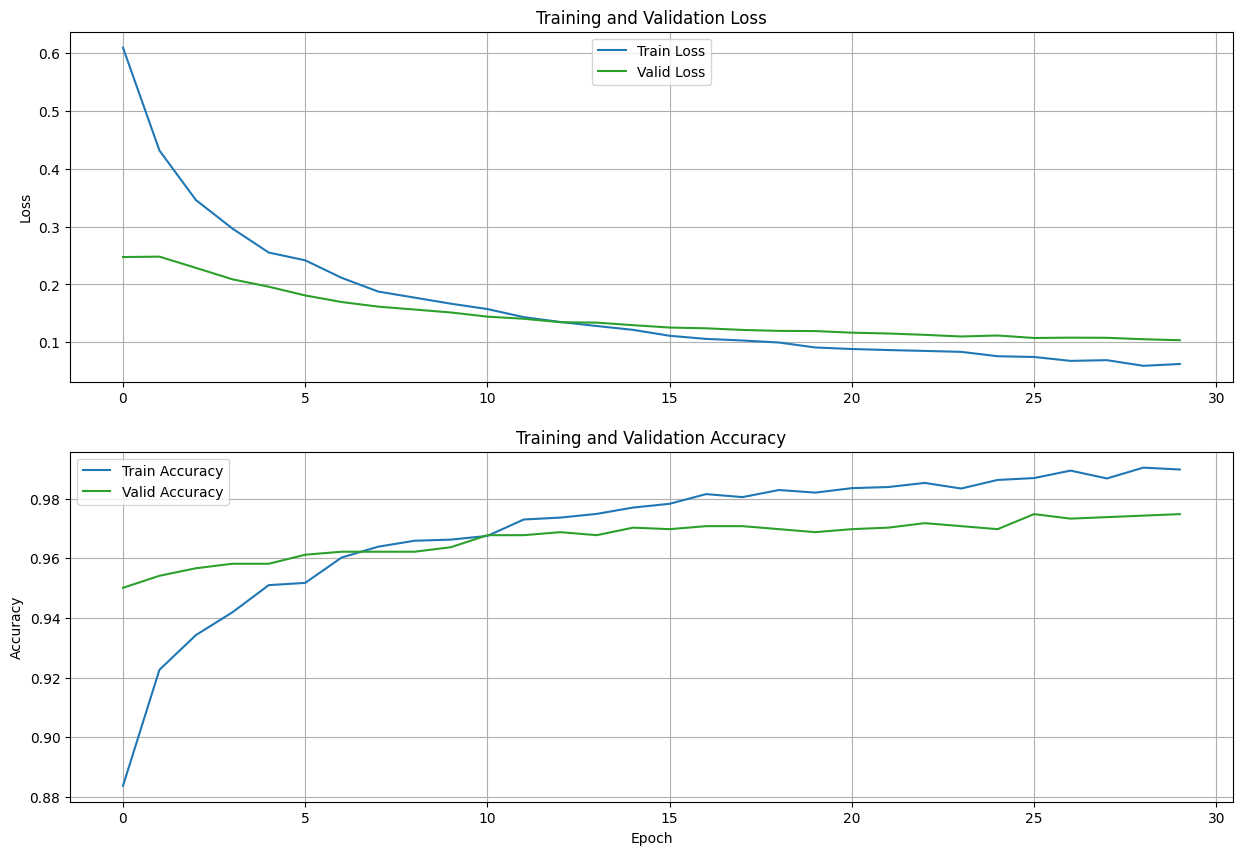

In [22]:
loss = training_results.history["loss"]
accuracy = training_results.history["accuracy"]

val_loss = training_results.history["val_loss"]
val_accuracy = training_results.history["val_accuracy"]

plot_history(
    train_loss=loss,
    train_metric=accuracy,
    val_loss=val_loss,
    val_metric=val_accuracy,
    loss_legend_loc="upper center",
    acc_legend_loc="upper left",
)

In [23]:
from IPython.testing import test
TEST_FILE = os.path.join(ROOT_DIR, "test.csv")

data_config = DatasetConfig()
training_config = TrainingConfig()
#split validation and train set
test_df = pd.read_csv(TEST_FILE)


idx_to_cls = {idx: name for name, idx in train_dataset.class_to_idx.items()}

predictions = []

for img_id in test_df['ID']:
    # load the image
    img_path = os.path.join(IMG_DIR, img_id)  # adjust path as needed
    img = tf.keras.utils.load_img(img_path, target_size=(300, 300,3))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

    # predict
    pred = fine_model.predict(img_array, verbose=0)
    class_idx = np.argmax(pred, axis=-1)[0]


    predictions.append(idx_to_cls[class_idx])

# 3. Create submission file
submission_df = pd.DataFrame({
    'ID': test_df['ID'],
    'CLASS': predictions
})

submission_df.to_csv('submission_fineTuned.csv', index=False)
print(submission_df.head())

           ID                 CLASS
0  687731.jpg           uneven_bars
1  158862.jpg            volleyball
2  660887.jpg  figure_skating_women
3  620977.jpg                  polo
4  522311.jpg              lacrosse


## <font style="color:red">4 Share TensorBoard Logs [10 Points]</font>

**Note:** In light of the recent shutdown of tensorboard.dev, we have updated the submission requirements for your project. Instead of sharing a tensorboard.dev link, you are now required to upload your generated TensorBoard event files directly onto the lab. As an alternative, you may also include a screenshot of your TensorBoard output within your Jupyter notebook. This adjustment ensures that your data visualization and model training efforts are thoroughly documented and accessible for evaluation.

## <font style="color:red">5 Kaggle Submission Score [70 Points]</font>


**For full points, you need a acheive atleast `92%` accuracy on the Public Test Leaderboard. If accuracy is less than `86%`, you gain no points for this section.**


**Submit `submission.csv` (prediction for images in `test.csv`), in the `Submit Predictions` tab in Kaggle, to get evaluated for  this section.**

<a href="https://www.kaggle.com/competitions/opencv-tf-project-2-image-classification-round-4" target="_blank">Kaggle Competition Link</a>

**Please share your profile link, user id and score achieved.**

1. **URL:https://www.kaggle.com/borislouis
2. **Profile Name: borislouis
3. **Points Scored: 93.895%

**Upon completing the project,  <font style="color:red">upload the notebook on the portal for feedback.</font>**


**<font style="color:red">Please do not make your notebooks public or publish them on the competition page. You only need to submit your notebook to the lab.</font>**